### *Small implemantation of the code (remember to read the Readme.txt):*

In [2]:
import pandas as pd
from functions import PhotometryTool

In the next cell I show how to implement the function *PhotometryTool* defined in the functions.py file (for more information about single tasks of the function you can look in the functions.py file where I hope you could find an exhaustive clarification of the way the function works).

I use the *read_csv* funtion of **pandas** to read the Radial and Declination coordinates of the stars of interest, from the file "Ra_Dec_comp_stars.txt" that I previously created searching on aavso catalogue to find possible comparison stars for "our" V0536 Peg.

The aperture photometry is then implemented by the function *PhotometryTool* that returns in output a dataframe containing the star aperture sum of DN, the sky anulus sum of DN and the instrumental magnitude, all refers to the stars taken in input. 

Finally I concatenate the output dataframe with the positions dataframe and display it.

In [3]:
positions = pd.read_csv('data/Ra_Deg_comp_stars.txt', names = ['Ra', 'Dec'])

dataset = PhotometryTool(path = 'data/2024-11-15_18-15-32_G_-20.00_80.00s_0000_cal.fits', 
                         ra_dec_coordinates=positions, 
                         r_star = 5, 
                         r_gap = 14, 
                         r_sky = 18)

dataset = pd.concat((positions, dataset), axis=1)
dataset = dataset.dropna(how='any')

display(dataset)

,Ra,Dec,star_aperture_sum,sky_aperture_sum,instrumental_magnitude
0,339.975790,13.437280,124135.350869,363714.328985,-11.529532
1,339.980072,13.320056,167123.328041,363936.040013,-12.172402
2,340.052917,13.471806,144970.805821,363817.896439,-11.887939
3,339.790375,13.319195,138858.808019,361941.153087,-11.799507
4,340.042542,13.533667,118213.686088,364074.941419,-11.399215
5,339.998505,13.593278,100207.905481,363546.920214,-10.878550
6,340.193542,13.436806,95593.654999,363236.234594,-10.696365
7,339.899048,13.371472,87314.100543,362226.954497,-10.265940
8,339.975790,13.437280,124135.350869,363714.328985,-11.529532


Now that it works for a single image, it could be useful to see how to implement it for a directory of fits image.

In the next cell I use the function *Path* from _pathlib_ to read the file names in the data directory and separate the fits file taken with the Blue filter from the ones taken using the Green filter, and I save the names in two separate list, so that it is easy to open the single files iterating through the list.

In [4]:
from pathlib import Path

files_blue_filter = []
files_green_filter = []

current_directory = Path.cwd()
directory = Path(current_directory / 'data')

# Iterate through all files in the directory
for file_path in directory.iterdir():
    if file_path.is_file():  # Check if it's a file
        if file_path.name.endswith('.fits'):    # Takes only files that ends with .fits
            if 'B' in file_path.name:   # Check if its a blue filtered image
                files_blue_filter.append(file_path.name)
            elif 'G' in file_path.name:     # Check if its a green filtered image
                files_green_filter.append(file_path.name)            


In the next cell I iterate throug the list of green filtered fits files (one can easely do it for blue filtered files just changing the name "green" with "blue" in the "for" line) and I do the same I did for one image, but for all the images. 
In the end I save the data in a list of pandas dataframe.

In [5]:
from tqdm import tqdm   # Just to visualize the loading in the loop for.

positions = pd.read_csv('data/Ra_Deg_comp_stars.txt', names = ['Ra', 'Deg'])
datasets = []

for i in tqdm(files_green_filter):
    dataset = PhotometryTool(path = Path(current_directory / 'data' / i), 
                            ra_dec_coordinates=positions, 
                            r_star = 4, 
                            r_gap = 12, 
                            r_sky = 17)

    dataset = pd.concat((positions, dataset), axis=1)
    dataset = dataset.dropna(how='any')
    datasets.append(dataset)

100%|██████████| 50/50 [05:26<00:00,  6.53s/it]


In the next cell I show how one can extract the information he wants from the list of dataframe obtained in the last cell. 
I use a compact "for" notation to take all the element of the list "datasets" from wich I extract the "instrumental magnitude" refers to the 0th, 1st, 2nd stars of the ra_dec_coordinates I use before. Then I plot the instrumental magnitude as an example, and the difference in instrumental magnitude between the 2 fixed stars (in wich I summed an offset just to make it visible in the plot with the other variables).

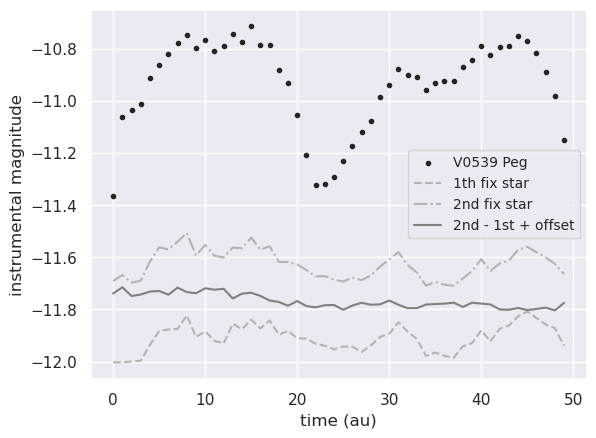

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting the instrumental magnitude of the 0th star (V0536 Peg), and the 1st and 2nd fixed stars
# for all the images.
instr_magnit_V0539Peg = [df['instrumental_magnitude'][0] for df in datasets]
instr_magnit_1 = [df['instrumental_magnitude'][1] for df in datasets]
instr_magnit_2 = [df['instrumental_magnitude'][2] for df in datasets]

# I define an offset just for visualization purpose
offset = -12.05
# Here I compute the difference between the 2 fixed stars plus the offset
diff_magnit_2_1 = [b - a + offset for a, b in zip(instr_magnit_1, instr_magnit_2)]

x = range(len(instr_magnit_V0539Peg))       # Define an arbitrary array just to visualize the instrumental magnitude.

# Here I do the plot
sns.set_theme(palette='grey')
fig, ax = plt.subplots()
ax.set(xlabel = 'time (au)', 
       ylabel = 'instrumental magnitude')
ax.scatter(x, instr_magnit_V0539Peg, marker='.', label = 'V0539 Peg')
ax.plot(x, instr_magnit_1, color = '0.7', linestyle = '--', label = '1th fix star')
ax.plot(x, instr_magnit_2, color = '0.7', linestyle = '-.', label = '2nd fix star')
ax.plot(x, diff_magnit_2_1 , color = '0.5', linestyle = '-', label = '2nd - 1st + offset')
plt.legend(loc = 'best', fontsize = 'small')
plt.show()


_IMPORTANT_: The image above is just an example, if one want to see the right plot of the periodicity of the instrumental magnitude, it is necessary to take the right time at wich correspond every point in the plot.